In [26]:
import pandas as pd

In [27]:
rbg = pd.read_excel('Research block grants time series 2021-2026.xlsx', sheet_name='Table 2', header=2)

comparators = ['University of Technology Sydney', 'Queensland University of Technology', 'Curtin University']
rbg_sub = rbg[rbg['HEP Name'].isin(comparators)]

rbg_totals = rbg_sub.groupby(['HEP Name', 'Year'])['Amount'].sum().reset_index()
rbg_totals = rbg_totals.rename(columns={'HEP Name': 'Institution', 'Amount': 'RBG_Total'})
rbg_totals

,Institution,Year,RBG_Total
0,Curtin University,2001,16844326
1,Curtin University,2002,17988215
2,Curtin University,2003,19626995
3,Curtin University,2004,20698287
4,Curtin University,2005,21733140
...,...,...,...
73,University of Technology Sydney,2022,42575185
74,University of Technology Sydney,2023,44449378
75,University of Technology Sydney,2024,47084992
76,University of Technology Sydney,2025,48273626


In [28]:
comp = pd.read_excel('Perturbed Award Course Completions Pivot Table 2024.xlsx', sheet_name='Pivot', skiprows=24)

comp['State'] = comp['State'].ffill()                                   
comp = comp.dropna(subset=['Institution'])                              
comp = comp[comp['Institution'] != 'Non-University Higher Education Providers']  

comp_sub = comp[comp['Institution'].isin(comparators)]
comp_long = comp_sub.melt(
    id_vars=['State', 'Institution'],
    value_vars=[2020, 2021, 2022, 2023, 2024],
    var_name='Year', value_name='Completions'
)
comp_long

,State,Institution,Year,Completions
0,New South Wales,University of Technology Sydney,2020,11960
1,Queensland,Queensland University of Technology,2020,10943
2,Western Australia,Curtin University,2020,9787
3,New South Wales,University of Technology Sydney,2021,8411
4,Queensland,Queensland University of Technology,2021,12200
5,Western Australia,Curtin University,2021,10076
6,New South Wales,University of Technology Sydney,2022,11273
7,Queensland,Queensland University of Technology,2022,11361
8,Western Australia,Curtin University,2022,10225
9,New South Wales,University of Technology Sydney,2023,10453


In [29]:
merged = pd.merge(rbg_totals, comp_long, on=['Institution', 'Year'])
merged['RBG_per_Completion'] = merged['RBG_Total'] / merged['Completions']
merged.sort_values(['Institution', 'Year'])

,Institution,Year,RBG_Total,State,Completions,RBG_per_Completion
0,Curtin University,2020,48012801,Western Australia,9787,4905.773066
1,Curtin University,2021,72099626,Western Australia,10076,7155.580191
2,Curtin University,2022,50218883,Western Australia,10225,4911.382200
3,Curtin University,2023,50684099,Western Australia,10255,4942.379230
4,Curtin University,2024,54457752,Western Australia,11834,4601.804293
5,Queensland University of Technology,2020,52474025,Queensland,10943,4795.213835
6,Queensland University of Technology,2021,72857176,Queensland,12200,5971.899672
7,Queensland University of Technology,2022,48384663,Queensland,11361,4258.838395
8,Queensland University of Technology,2023,52786093,Queensland,10535,5010.545135
9,Queensland University of Technology,2024,56855908,Queensland,11488,4949.156337


In [31]:
t3 = pd.read_excel('Research block grants time series 2021-2026.xlsx', sheet_name='Table 3', header=2)
t3 = t3[t3['HEP Name'].isin(comparators)][['HEP Name', 'Additional RSP']].rename(columns={'HEP Name': 'Institution'})

print('Duplicate rows:', rbg_sub.duplicated(['HEP Name', 'Year', 'Program']).sum()) 
print(rbg_sub[(rbg_sub['Year'] == 2021) & (rbg_sub['Program'] == 'RSP')][['HEP Name', 'Amount']]) 

rbg_adj = rbg_totals.merge(t3, on='Institution', how='left')
rbg_adj['Additional RSP'] = rbg_adj['Additional RSP'].where(rbg_adj['Year'] == 2021, 0)
rbg_adj['RBG_Base'] = rbg_adj['RBG_Total'] - rbg_adj['Additional RSP']

pc = rbg_adj[rbg_adj['Year'].isin([2015, 2026])].pivot(index='Institution', columns='Year', values='RBG_Total')
pc['pct_change'] = (pc[2026] / pc[2015] - 1) * 100
print(pc)

kpi = pd.merge(rbg_adj, comp_long, on=['Institution', 'Year'])
kpi['Base_RBG_per_Completion'] = kpi['RBG_Base'] / kpi['Completions']
kpi.to_csv('kpi_table.csv', index=False)
kpi

Duplicate rows: 0
                                HEP Name    Amount
436                    Curtin University  44273982
458  Queensland University of Technology  42026223
498      University of Technology Sydney  34008775
Year                                     2015      2026  pct_change
Institution                                                        
Curtin University                    39229674  56365535   43.680865
Queensland University of Technology  47609881  57751236   21.300946
University of Technology Sydney      26076110  50346535   93.075328


,Institution,Year,RBG_Total,Additional RSP,RBG_Base,State,Completions,Base_RBG_per_Completion
0,Curtin University,2020,48012801,0.000000e+00,4.801280e+07,Western Australia,9787,4905.773066
1,Curtin University,2021,72099626,2.299845e+07,4.910117e+07,Western Australia,10076,4873.081865
2,Curtin University,2022,50218883,0.000000e+00,5.021888e+07,Western Australia,10225,4911.382200
3,Curtin University,2023,50684099,0.000000e+00,5.068410e+07,Western Australia,10255,4942.379230
4,Curtin University,2024,54457752,0.000000e+00,5.445775e+07,Western Australia,11834,4601.804293
5,Queensland University of Technology,2020,52474025,0.000000e+00,5.247402e+07,Queensland,10943,4795.213835
6,Queensland University of Technology,2021,72857176,2.116529e+07,5.169189e+07,Queensland,12200,4237.040106
7,Queensland University of Technology,2022,48384663,0.000000e+00,4.838466e+07,Queensland,11361,4258.838395
8,Queensland University of Technology,2023,52786093,0.000000e+00,5.278609e+07,Queensland,10535,5010.545135
9,Queensland University of Technology,2024,56855908,0.000000e+00,5.685591e+07,Queensland,11488,4949.156337


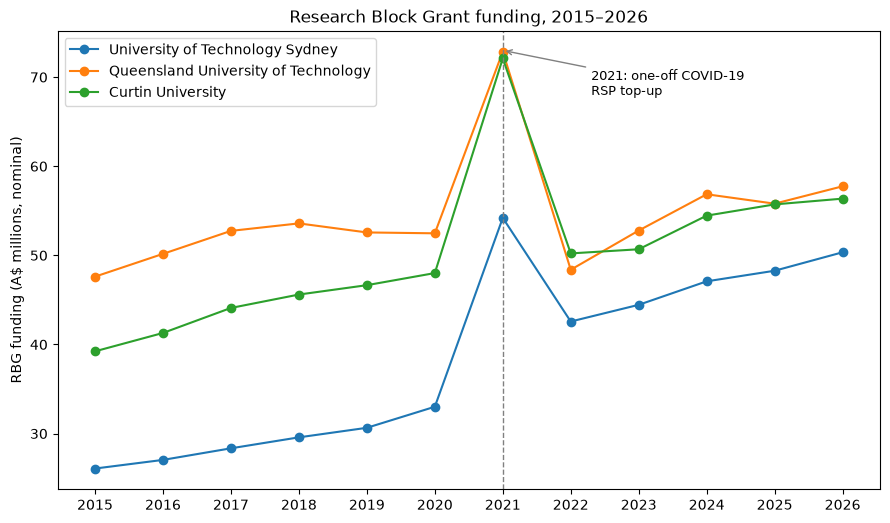

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5.5))
d_all = rbg_adj[rbg_adj['Year'] >= 2015]
for uni in comparators:
    d = d_all[d_all['Institution'] == uni]
    ax.plot(d['Year'], d['RBG_Total'] / 1e6, marker='o', label=uni)
ax.axvline(2021, color='grey', ls='--', lw=1)
ax.annotate('2021: one-off COVID-19\nRSP top-up', xy=(2021, 73), xytext=(2022.3, 68),
            arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9)
ax.set_xticks(range(2015, 2027))
ax.set_ylabel('RBG funding (A$ millions, nominal)')
ax.set_title('Research Block Grant funding, 2015–2026')
ax.legend(loc='upper left')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('finding1_rbg_trend.png', dpi=150)
plt.show()

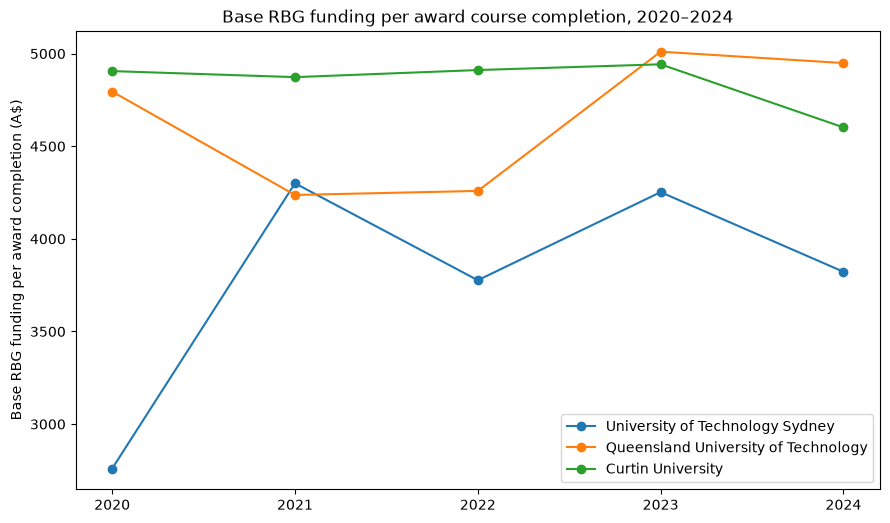

In [34]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for uni in comparators:
    d = kpi[kpi['Institution'] == uni]
    ax.plot(d['Year'], d['Base_RBG_per_Completion'], marker='o', label=uni)
ax.set_xticks([2020, 2021, 2022, 2023, 2024])
ax.set_ylabel('Base RBG funding per award completion (A$)')
ax.set_title('Base RBG funding per award course completion, 2020–2024')
ax.legend()
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('finding2_efficiency.png', dpi=150)
plt.show()